# Fast Example: Lifetime based analysis

Paul, write this quick tutorial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

## Pre-processing: Burst Search and Correction Factors

First we load the data

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

Then make burst searches to compute correction factors 
(see the [correction factors tutorial](FRETCorrectionsTutorial.ipynb) for more detailed tutorial of how to compute these).
Corrections are needed for accurate FRET, which is necessary for E-$\tau$ analysis.

In [3]:
# Background analysis
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4)
# burst search for correction factors
dbs_acbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex_1ex1em'),))
gate_acbs = smf.make_geq_gate(dbs_acbs['NphActive_bg'], 50.0)
# burst search (dcbs) for E-tau analysis
dbs_dcbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
gate_dcbs = smf.make_geq_gate(dbs_dcbs['NphDex_bg'], 50.0) & smf.make_geq_gate(dbs_dcbs['NphAA_bg'], 30.0)

Plot and define thresholds for DO, AO and FRET populations

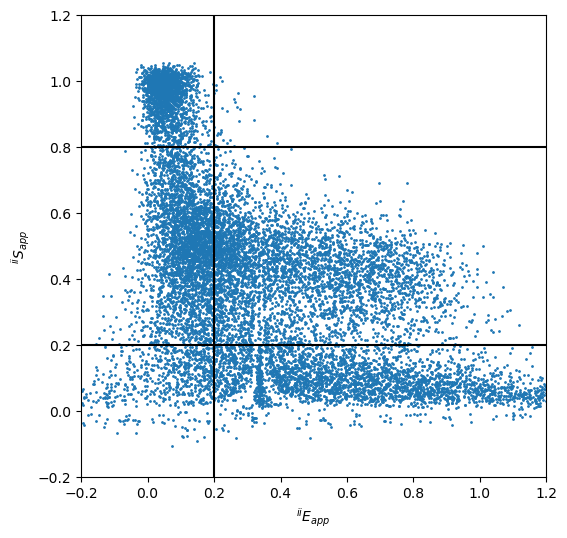

In [4]:
DO_thresh = 0.8
DO_ethresh = 0.2
AO_thresh = 0.2

fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_acbs['E_bg'], dbs_acbs['S_bg'], gate=gate_acbs, ax=ax, s=1.0)
ax.axhline(DO_thresh, c='k')
ax.axvline(DO_ethresh, c='k')
ax.axhline(AO_thresh, c='k')

ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2]);

Build gates and compute $\alpha$ and $\delta$ cross-talk corrections

In [5]:
gate_do = gate_acbs & smf.make_geq_gate(dbs_acbs['S_bg'], DO_thresh) & smf.make_lt_gate(dbs_acbs['E_bg'], DO_ethresh)
gate_ao = gate_acbs & smf.make_lt_gate(dbs_acbs['S_bg'], AO_thresh)

alpha = smf.fretfactory.crosstalk_correction(data, dbs_acbs['E_bg'], gate=gate_do)
delta = smf.fretfactory.crosstalk_correction(data, dbs_acbs['S_bg'], gate=gate_ao)

dbs_dcbs_ct = smf.fretfactory.make_correction_factors(dbs_dcbs['nphbg'], alpha=alpha, delta=delta)

Check FRET populations.

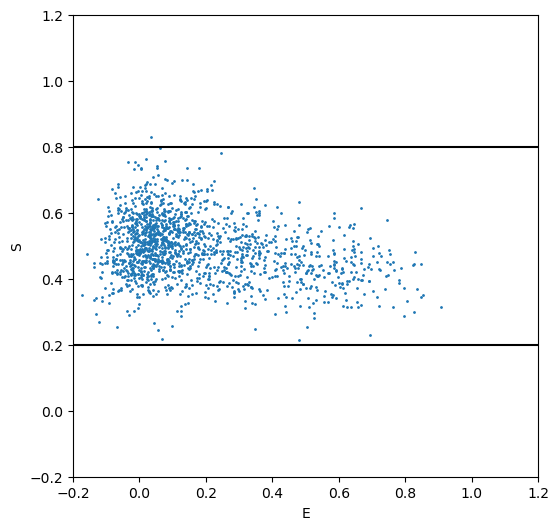

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
smf.plot.scatter(data, dbs_dcbs_ct['E'], dbs_dcbs_ct['S'], gate=gate_dcbs, ax=ax, s=1.0)
ax.axhline(AO_thresh, c='k')
ax.axhline(DO_thresh, c='k')

ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2]);

In this case the dcbs looks good, we can use the global burst fit without further gating. In other cases, you may want to set $S$ thresholds to isolate the FRET population, or fit positions.

We can now compute the $\gamma$ and $\beta$ values.

In [7]:
gamma, beta = smf.fretfactory.gamma_beta_bursts(data, dbs_dcbs_ct['E'], dbs_dcbs_ct['S'], gate=gate_dcbs)
dbs_dcbs_full = smf.fretfactory.make_correction_factors(dbs_dcbs['nphbg'], alpha=alpha, delta=delta, gamma=gamma, beta=beta)

## E-$\tau$ analysis

To compute mean lifetimes, we must first set thresholds for excluding the IRF from computation of mean lifetimes.

We can visualize the decays by summing the `nanohist` column:

In [8]:
Nhst_DD = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('0ex0em'), True))
hstDD = data.get_column(Nhst_DD, gate=gate_dcbs).sum(axis=0)
Nhst_DA = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('0ex1em'), True))
hstDA = data.get_column(Nhst_DA, gate=gate_dcbs).sum(axis=0)
Nhst_AA = smf.Column(dbs_dcbs['bursts'], 'nanohist', (smf.PhSel('1ex1em'), True))
hstAA = data.get_column(Nhst_AA, gate=gate_dcbs).sum(axis=0)

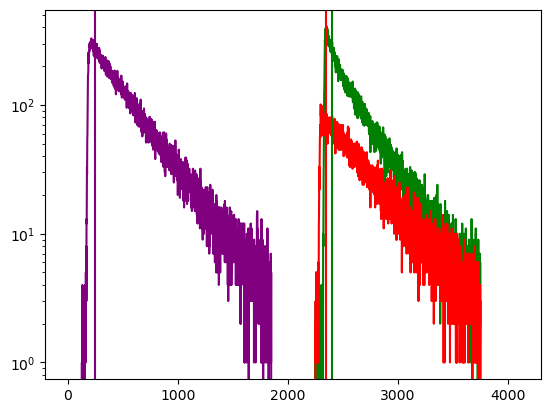

In [9]:
plt.semilogy(hstDD, label='DD', c='g')
plt.semilogy(hstDA, label='DA', c='r')
plt.semilogy(hstAA, label='AA', c='purple')

threshDD = 2400
threshDA = 2350
threshAA = 250

plt.axvline(threshDD, c='g')
plt.axvline(threshDA, c='r')
plt.axvline(threshAA, c='purple')

Now that the thresholds to exclude the IRF are decided, we set the `data.irf_thresh` dictionary accordingly:

In [10]:
data.irf_thresh = {smf.PhSel('0ex0em'):threshDD, smf.PhSel('0ex1em'):threshDA, smf.PhSel('1ex1em'):threshAA}

And we can define the column for mean lifetime:

In [11]:
nanomean = smf.Column(dbs_dcbs['bursts'], 'nanomean', smf.PhSel('0ex0em'))

A simple histogram plot will only show as much as a standard FRET histogram:

(array([  0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   1,   4,   2,
          1,   4,   2,   7,   3,   3,   5,   6,   8,  10,  17,  18,  32,
         37,  42,  59,  71,  79,  97,  99, 125,  86, 110,  95,  80,  75,
         78,  58,  50,  35,  25,  24,  14,  18,   5,   4]),
 array([0.        , 0.10204082, 0.20408163, 0.30612245, 0.40816327,
        0.51020408, 0.6122449 , 0.71428571, 0.81632653, 0.91836735,
        1.02040816, 1.12244898, 1.2244898 , 1.32653061, 1.42857143,
        1.53061224, 1.63265306, 1.73469388, 1.83673469, 1.93877551,
        2.04081633, 2.14285714, 2.24489796, 2.34693878, 2.44897959,
        2.55102041, 2.65306122, 2.75510204, 2.85714286, 2.95918367,
        3.06122449, 3.16326531, 3.26530612, 3.36734694, 3.46938776,
        3.57142857, 3.67346939, 3.7755102 , 3.87755102, 3.97959184,
        4.08163265, 4.18367347, 4.28571429, 4.3877551 , 4.48979592,
        4.59183673, 4.69387755, 4.79591837, 4.89795918, 5.        ]),
 <BarContainer object of 49 artists>,
 

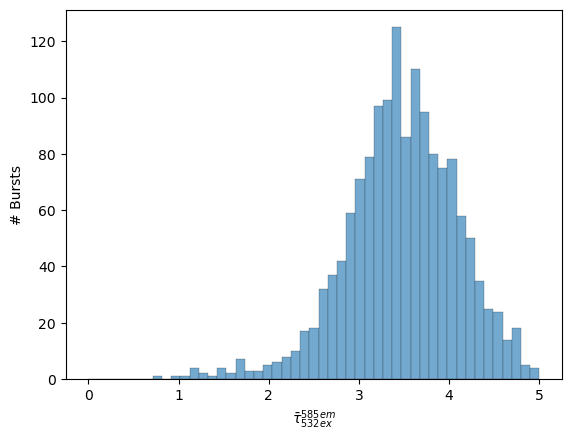

In [12]:
smf.plot.hist_bar(data, nanomean, gate=gate_dcbs, rescale=-9, bins=np.linspace(0, 5.0, 50), **smf.fretfactory.ALEXdefaults['histbar'])

But plotting E vs $\tau$ can show evidence of dynamics (if the expected 0 fret lifetime is known)

(<matplotlib.collections.PathCollection at 0x7c2fab6e4710>,
 Text(0.5, 0, 'E'),
 Text(0, 0.5, '$\\bar \\tau_{532ex}^{585em}\\: (ns)$'))

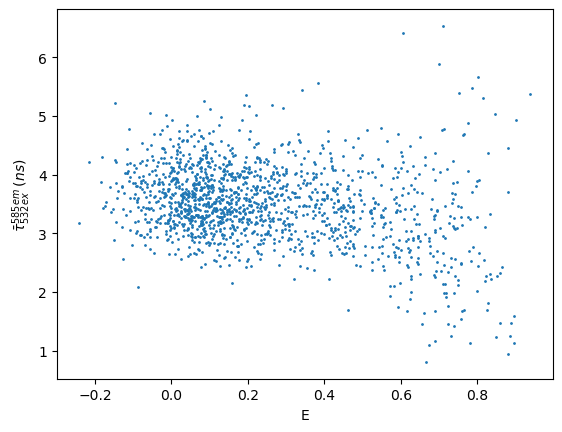

In [13]:
smf.plot.scatter(data, dbs_dcbs_full['E'], nanomean, gate=gate_dcbs, s=1.0, rescale=(0, -9))

## Publication Recomendations

### Citations

Of course, after we are done we should remember to print out the citations wtih `smf.print_citations()` 
(or get them with `smf.get_citations()` instead for a more detailed list)

In [14]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
3. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).
4. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).


### Print Params

It is also recomended to get descriptions of the parameters used for the analysis.

All `Param`, `Column`, and `GateGroup` objects have a `.description` property.
Printing this will generate a yaml-like string that is good to add to your supplementary data, as it exactly describes the object.

Since we always used the `gate` as our gate, we can fold the gate into the description with the `.regate()` method.
You should select at a minimum the key Columns used in your anlalysis.
Also note that this is a full description, so a `Column` description will include the description of the `Param` on which it is based.

In [15]:
print(nanomean.regate(gate_dcbs).description)

Column: Bursts, nanomean, 0ex0em
  Params:
    streams: (1ex1em, 0ex)
    m: [10 10]
    F: [6. 6.]
    c: [-1. -1.]
    truthtable: [[False False]
                 [False  True]]
    fuse: [0. 0.]
    asP: [False False]
  Parents:
    bg:
      - Table: BG
        Params:
          compute_stream: single_all
          func: smfbursts.background.exp_mlefit
          tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
          auto_threshold: True
          F_bg: 2.0
        Parents:
          base:
            Table: Periods
            Params:
              period: 60.0
              start_at: time_min
              stop_at: over
              detdef: DetDef2ex2em  - Table: BG
        Params:
          compute_stream: single_all
          func: smfbursts.background.exp_mlefit
          tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
          auto_threshold: True
          F_bg: 2.0
        Parents:
          base:
            Table: Periods
            Params:
              period: 60.0
 